<a href="https://colab.research.google.com/github/KeshavaOfficial/DataScience-Projects/blob/Projects/Bagging_and_Boosting_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [135]:
!pip install scikit-learn
import sklearn
print(sklearn.__version__)


1.6.1


In [136]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [137]:
df = pd.read_csv("/content/glass.csv")

In [138]:
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1.0
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1.0
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1.0
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1.0
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1.0


In [139]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    float64
dtypes: float64(10)
memory usage: 78.2 KB


#Many Null Values


In [140]:
df.isnull().sum()

,0
RI,785
Na,785
Mg,785
Al,785
Si,785
K,785
Ca,785
Ba,785
Fe,785
Type,785


In [141]:
df

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1.0
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1.0
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1.0
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1.0
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...
994,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#Lets Visualize

<Axes: ylabel='Count'>

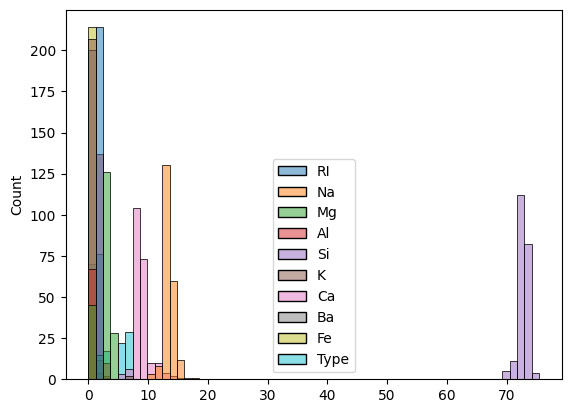

In [142]:
sns.histplot(df)

<Axes: xlabel='RI', ylabel='Count'>

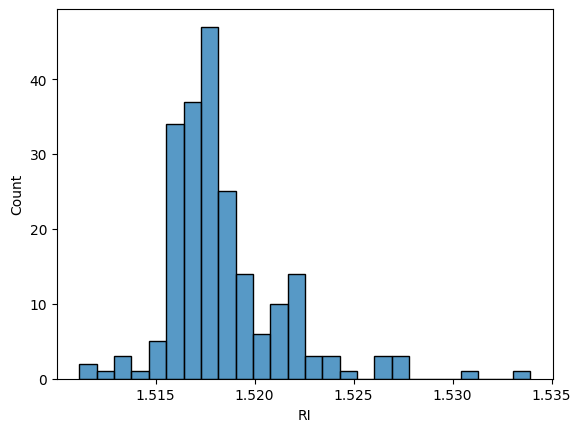

In [143]:
sns.histplot(df['RI'])

<Axes: >

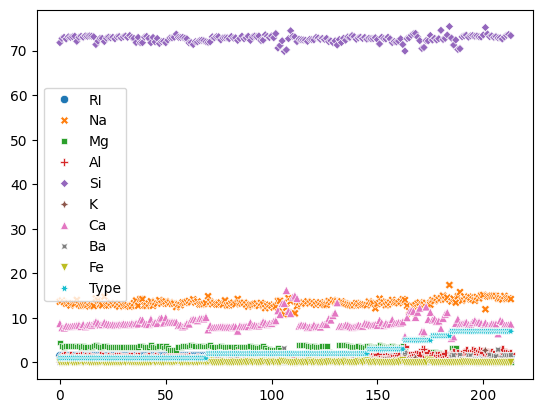

In [144]:
sns.scatterplot(df)

<Axes: >

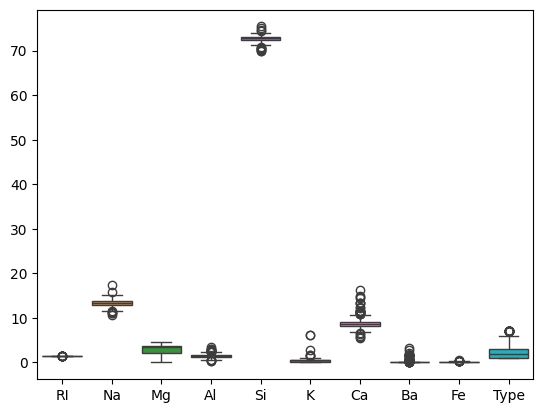

In [145]:
sns.boxplot(df)

#Silicon looks like a Outlier so i am dropping Silicon

In [146]:
df= df.drop('Si',axis=1)

<Axes: >

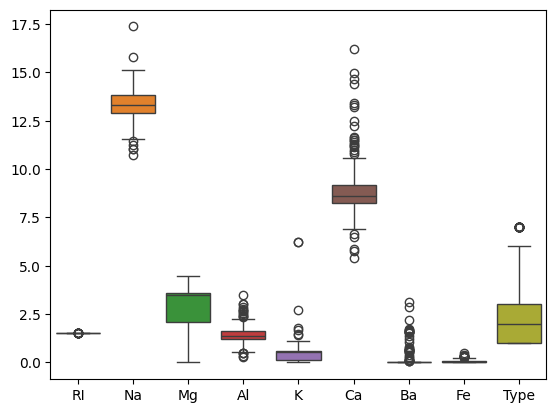

In [147]:
sns.boxplot(df)

<Axes: >

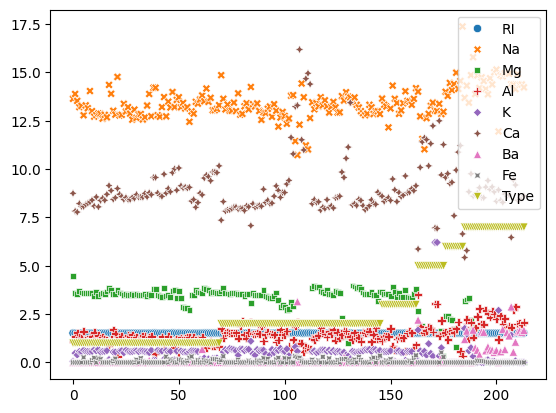

In [148]:
sns.scatterplot(df)

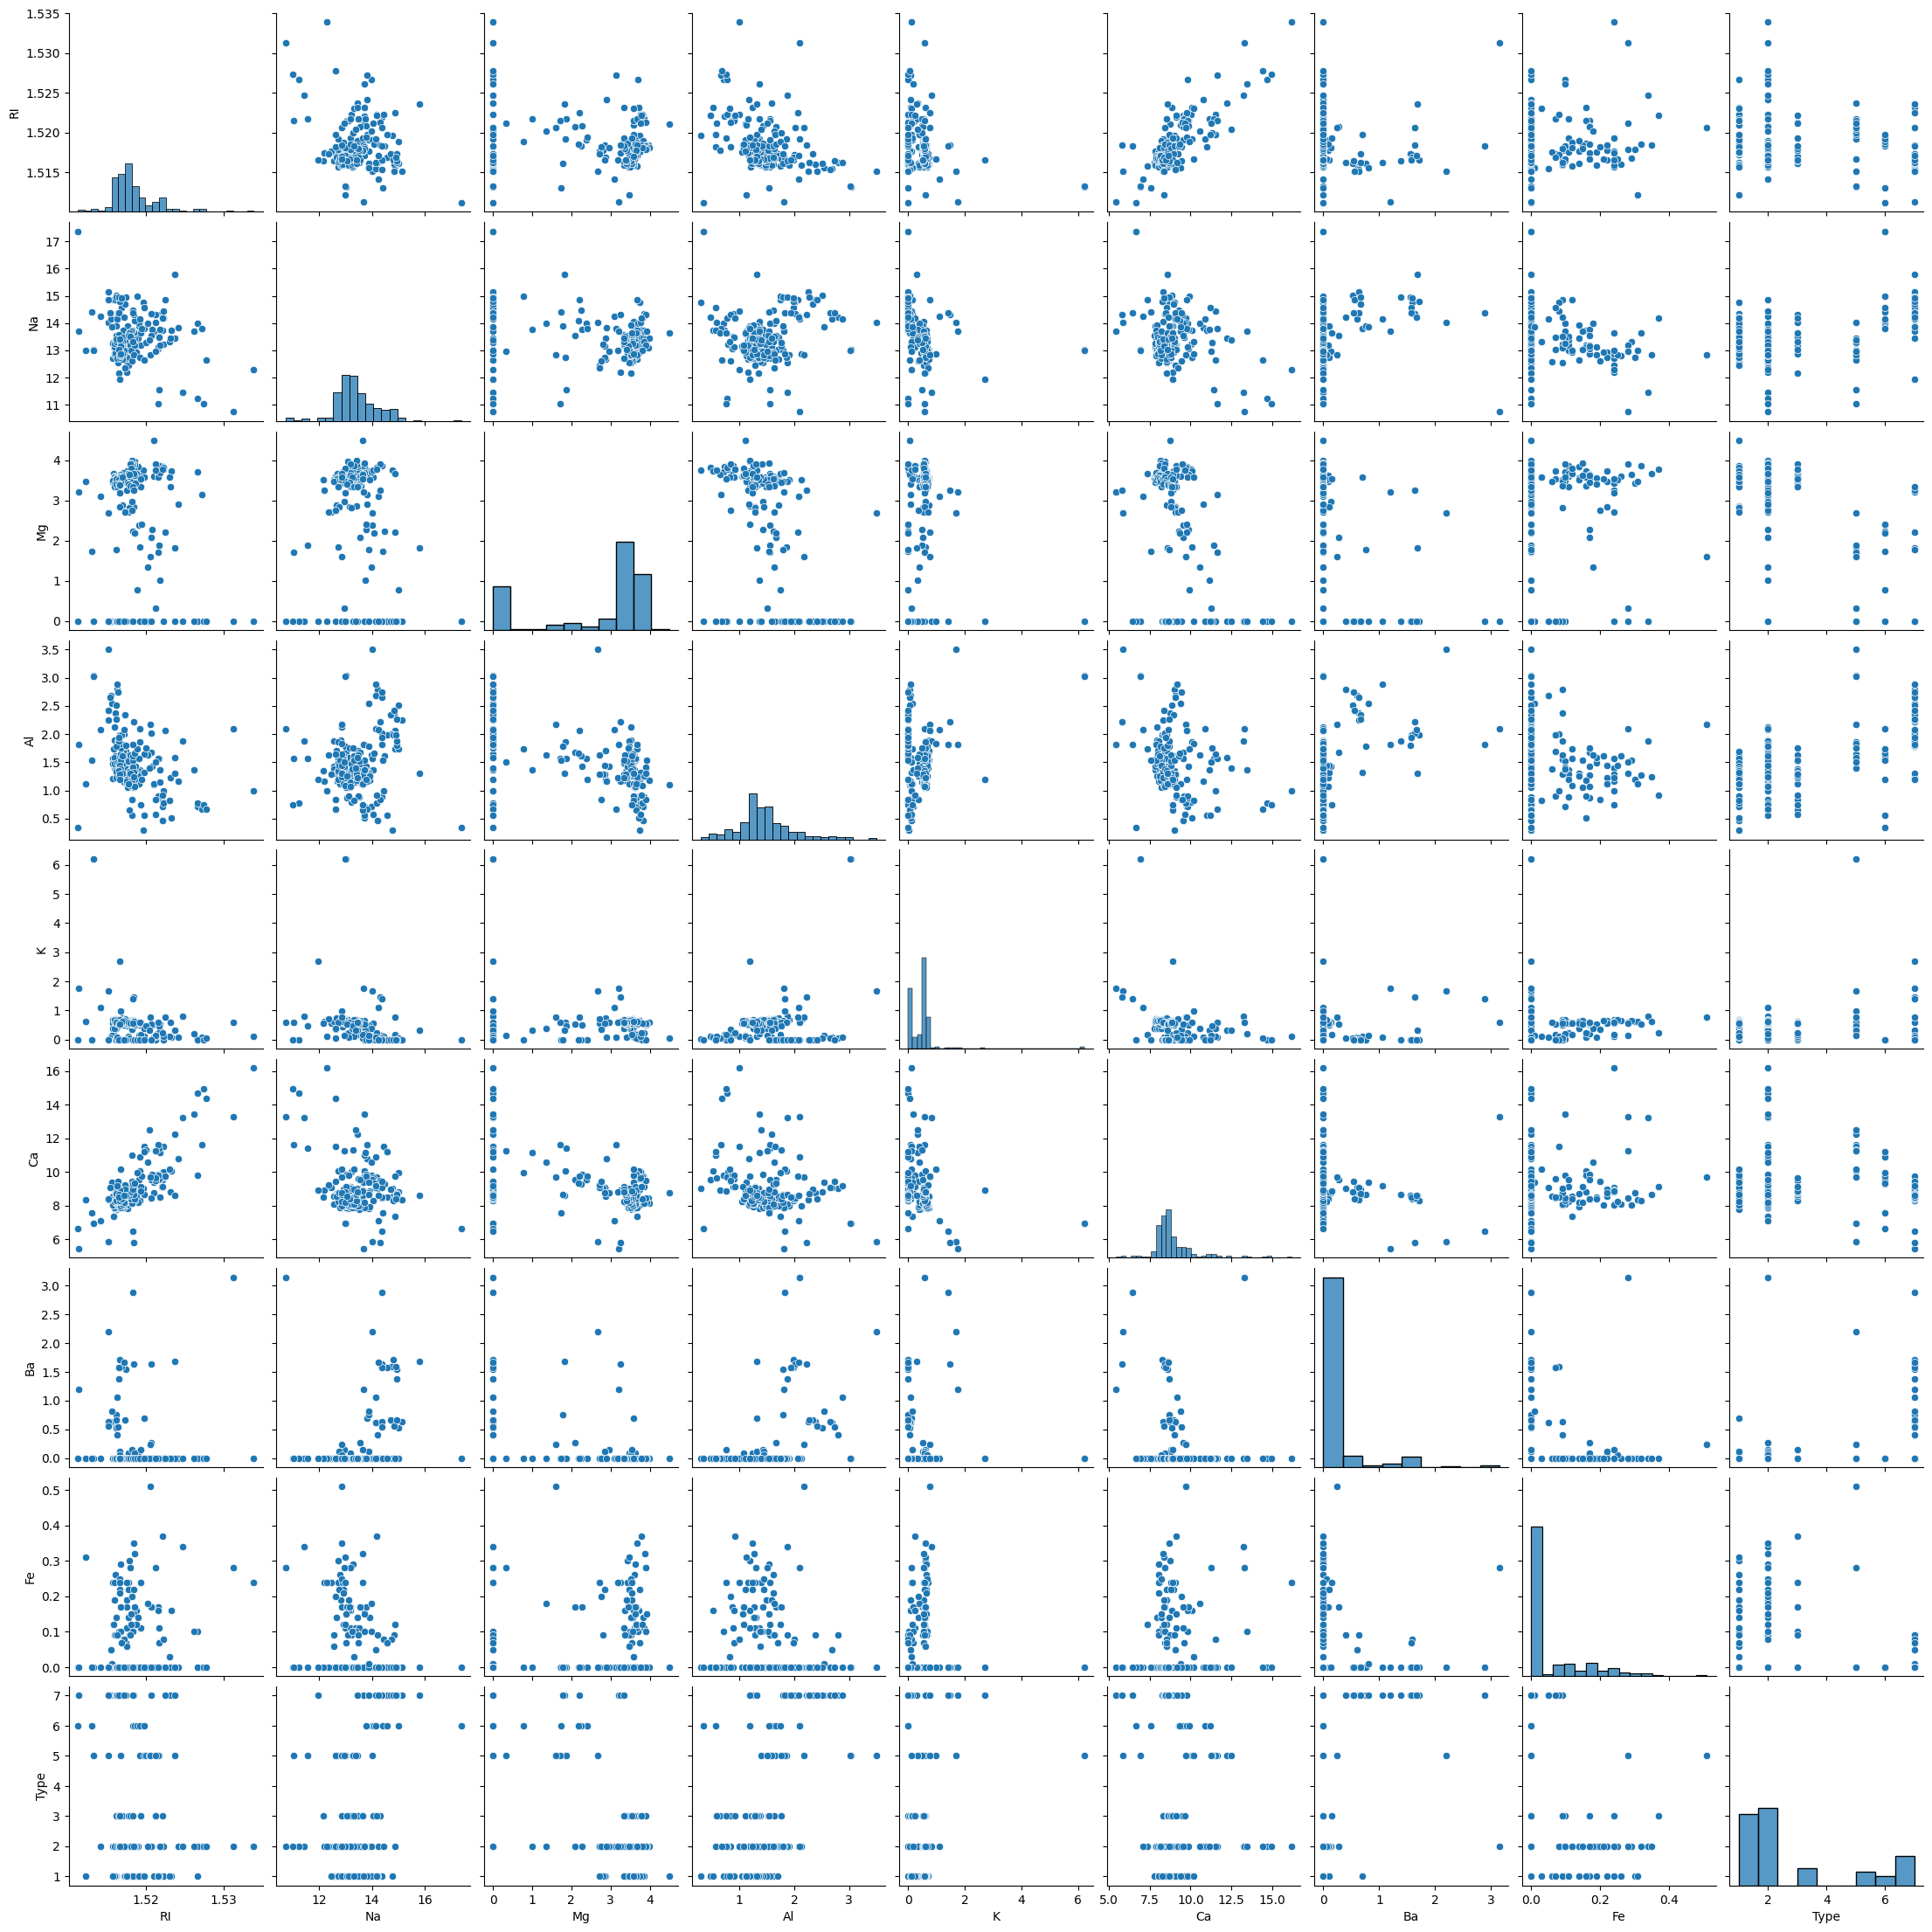

In [149]:
sns.pairplot(df)

<Axes: >

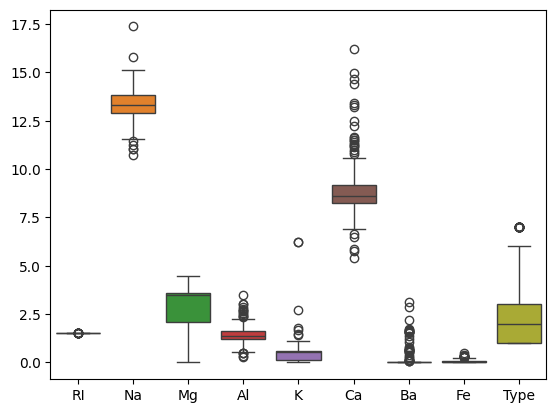

In [150]:
sns.boxplot(df)

<Axes: ylabel='Count'>

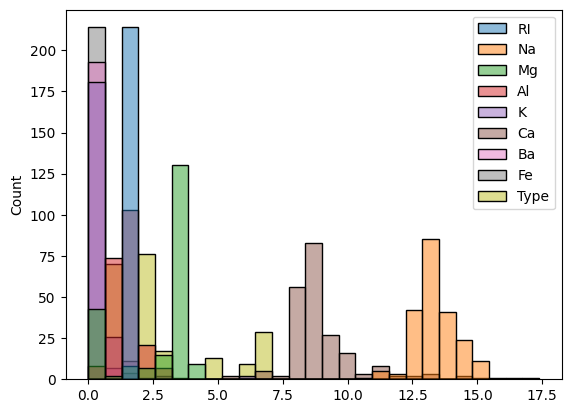

In [151]:
sns.histplot(df)

In [152]:
df.isnull().sum()

,0
RI,785
Na,785
Mg,785
Al,785
K,785
Ca,785
Ba,785
Fe,785
Type,785


#using Simple imputer to Impute zero values in The table

In [153]:
x = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [154]:
y

,Type
0,1.0
1,1.0
2,1.0
3,1.0
4,1.0
...,...
994,NaN
995,NaN
996,NaN
997,NaN


In [155]:
y.isnull().sum()

np.int64(785)

In [156]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
imputer.fit(x)
x = imputer.transform(x)


In [157]:
imputed = pd.DataFrame(x)

In [158]:
imputed.columns = df.columns[:-1]

In [159]:
imputed

,RI,Na,Mg,Al,K,Ca,Ba,Fe
0,1.521010,13.64000,4.490000,1.100000,0.060000,8.750000,0.000000,0.000000
1,1.517610,13.89000,3.600000,1.360000,0.480000,7.830000,0.000000,0.000000
2,1.516180,13.53000,3.550000,1.540000,0.390000,7.780000,0.000000,0.000000
3,1.517660,13.21000,3.690000,1.290000,0.570000,8.220000,0.000000,0.000000
4,1.517420,13.27000,3.620000,1.240000,0.550000,8.070000,0.000000,0.000000
...,...,...,...,...,...,...,...,...
994,1.518365,13.40785,2.684533,1.444907,0.497056,8.956963,0.175047,0.057009
995,1.518365,13.40785,2.684533,1.444907,0.497056,8.956963,0.175047,0.057009
996,1.518365,13.40785,2.684533,1.444907,0.497056,8.956963,0.175047,0.057009
997,1.518365,13.40785,2.684533,1.444907,0.497056,8.956963,0.175047,0.057009


#Imputing Y value Using MODE imputation

In [160]:
y = y.fillna(y.mode()[0])

#NO Categorical values the values in dataset are already encoded

In [161]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x = scaler.fit_transform(imputed)

In [162]:
x = pd.DataFrame(x)

In [163]:
x.columns = df.columns[:-1]

In [164]:
x.head()

,RI,Na,Mg,Al,K,Ca,Ba,Fe
0,1.885924,0.615672,2.710781,-1.496095,-1.451292,-0.314944,-0.762428,-1.26709
1,-0.538712,1.278685,1.374509,-0.368298,-0.056637,-1.714947,-0.762428,-1.26709
2,-1.558485,0.323947,1.299438,0.412485,-0.355491,-1.791034,-0.762428,-1.26709
3,-0.503055,-0.524709,1.509638,-0.671935,0.242218,-1.121467,-0.762428,-1.26709
4,-0.674206,-0.365586,1.404538,-0.888820,0.175806,-1.349729,-0.762428,-1.26709


In [165]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [166]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model.fit(x_train, y_train)

RandomForestClassifier()

In [167]:
y_pred = model.predict(x_test)

In [168]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
accuracy = accuracy_score(y_test, y_pred)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy)

Confusion Matrix:
[[ 12   2   0   0   0   0]
 [  3 173   0   0   0   0]
 [  0   0   1   0   0   0]
 [  0   1   0   1   0   0]
 [  0   0   0   0   1   0]
 [  0   0   0   0   0   6]]

Classification Report:
              precision    recall  f1-score   support

         1.0       0.80      0.86      0.83        14
         2.0       0.98      0.98      0.98       176
         3.0       1.00      1.00      1.00         1
         5.0       1.00      0.50      0.67         2
         6.0       1.00      1.00      1.00         1
         7.0       1.00      1.00      1.00         6

    accuracy                           0.97       200
   macro avg       0.96      0.89      0.91       200
weighted avg       0.97      0.97      0.97       200

Accuracy: 0.97


In [182]:
from sklearn.ensemble import BaggingClassifier
bagging_model = BaggingClassifier( n_estimators=5, random_state=42)
bagging_model.fit(x_train, y_train)

BaggingClassifier(n_estimators=5, random_state=42)

In [183]:
y_pred = bagging_model.predict(x_test)

#By hyper ParaTunning  n_estimators in Bagging Model i have achive 96 % Accuracy

In [184]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
accuracy = accuracy_score(y_test, y_pred)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[ 12   1   1   0   0   0]
 [  2 173   1   0   0   0]
 [  0   1   0   0   0   0]
 [  0   1   0   1   0   0]
 [  0   0   0   0   1   0]
 [  0   0   0   0   0   6]]

Classification Report:
              precision    recall  f1-score   support

         1.0       0.86      0.86      0.86        14
         2.0       0.98      0.98      0.98       176
         3.0       0.00      0.00      0.00         1
         5.0       1.00      0.50      0.67         2
         6.0       1.00      1.00      1.00         1
         7.0       1.00      1.00      1.00         6

    accuracy                           0.96       200
   macro avg       0.81      0.72      0.75       200
weighted avg       0.97      0.96      0.97       200



#By hyper para tunning iin boosting i have achived 94% accuracy

In [208]:
from sklearn.ensemble import AdaBoostClassifier
adaboost_model = AdaBoostClassifier(n_estimators=20, random_state=42)
adaboost_model.fit(x_train, y_train)
y_pred = adaboost_model.predict(x_test)

In [209]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
accuracy = accuracy_score(y_test, y_pred)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[ 10   3   1   0   0   0]
 [  4 171   1   0   0   0]
 [  0   1   0   0   0   0]
 [  0   2   0   0   0   0]
 [  0   0   0   1   0   0]
 [  0   0   0   0   0   6]]

Classification Report:
              precision    recall  f1-score   support

         1.0       0.71      0.71      0.71        14
         2.0       0.97      0.97      0.97       176
         3.0       0.00      0.00      0.00         1
         5.0       0.00      0.00      0.00         2
         6.0       0.00      0.00      0.00         1
         7.0       1.00      1.00      1.00         6

    accuracy                           0.94       200
   macro avg       0.45      0.45      0.45       200
weighted avg       0.93      0.94      0.93       200



#By applying RandomForest i have achieved 97% accuracy with 20% and 80% training data, and applying Bagging model decreased my accuracy to 96 % and by applying AdaBoost model my accuracy has reduced to 94%. Since RandomForest Model given high Accuracy i choose Random Forest MOdel for Deploment

Bagging (Bootstrap Aggregating) reduces variance by training multiple models independently on different random subsets of data and aggregating their predictions (e.g., Random Forest). It prevents overfitting and works well with high-variance models.

Boosting reduces bias by training models sequentially, where each model corrects errors from the previous one (e.g., AdaBoost, XGBoost). It enhances weak models but may lead to overfitting if not tuned properly.

Key Difference: Bagging runs models in parallel, reducing variance, while Boosting runs models sequentially, reducing bias.

#Explain how to handle imbalance in the data.

Resampling Techniques – Use oversampling (SMOTE) to duplicate minority class samples or undersampling to remove majority class samples.

Class Weighting – Assign higher weights to the minority class during model training.

Synthetic Data Generation – Use SMOTE or GANs to generate synthetic samples for the minority class.

Anomaly Detection Models – Train models like Isolation Forests if minority class instances are rare events.

Use Different Evaluation Metrics – Focus on Precision-Recall, F1-score, and AUC-ROC instead of accuracy.

Ensemble Methods – Use Bagging and Boosting techniques to balance the learning from both classes.








